In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
# AT => temperature 
# v => vaccum
# AP => pressure
# RH => humidity

# PE => Energy produced

In [5]:
df.shape

(9568, 5)

In [6]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [7]:
X = df.drop("PE",axis=1)
y = df["PE"]

In [8]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [9]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [10]:
# split
from sklearn.model_selection import train_test_split

X_train , X_test ,y_train ,y_test = train_test_split(
    X ,y ,test_size = 0.2 ,random_state = 42
)

In [11]:
# scaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]],
      shape=(7654, 4))

In [13]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]],
      shape=(1914, 4))

In [14]:
import torch
import torch.nn as nn

In [15]:
X_train_tensor = torch.tensor(X_train_scaled ,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values ,dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled ,dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values ,dtype=torch.float32).view(-1,1)


In [16]:
type(X_train_scaled)

numpy.ndarray

In [17]:
type(y_train)

pandas.core.series.Series

In [18]:
from torch.utils.data import DataLoader ,TensorDataset

train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

In [19]:
train_loader = DataLoader(train_dataset , batch_size =32 ,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size =32)

## Deep Learning

In [36]:
# Define our ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
    
            # 2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),
    
            # output layer
            nn.Linear(6, 1),
        )

    def forward(self, x):
        return self.model(x)

In [37]:
import torch.optim as optim

model = ANN()

# loss, optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [38]:
# Train the ANN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch
    
    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()
        
        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = crietrion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update
        
        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #.pt or .pth

epoch 1/100 ==> train loss = 205961.87740885417 & val loss = 203109.59375
epoch 2/100 ==> train loss = 194013.53483072916 & val loss = 179958.265625
epoch 3/100 ==> train loss = 160788.6921875 & val loss = 140302.8125
epoch 4/100 ==> train loss = 126494.98160807292 & val loss = 115309.6328125
epoch 5/100 ==> train loss = 110291.45823567708 & val loss = 103243.78125
epoch 6/100 ==> train loss = 96198.11980794271 & val loss = 83806.6484375
epoch 7/100 ==> train loss = 70375.93774414062 & val loss = 50338.2734375
epoch 8/100 ==> train loss = 31729.194417317707 & val loss = 13788.6494140625
epoch 9/100 ==> train loss = 6468.25540822347 & val loss = 2118.3408203125
epoch 10/100 ==> train loss = 1438.6927159627278 & val loss = 1009.7415161132812
epoch 11/100 ==> train loss = 953.9842892964681 & val loss = 818.8253173828125
epoch 12/100 ==> train loss = 795.4064128875732 & val loss = 694.6448974609375
epoch 13/100 ==> train loss = 669.8899349212646 & val loss = 590.3492431640625
epoch 14/100 

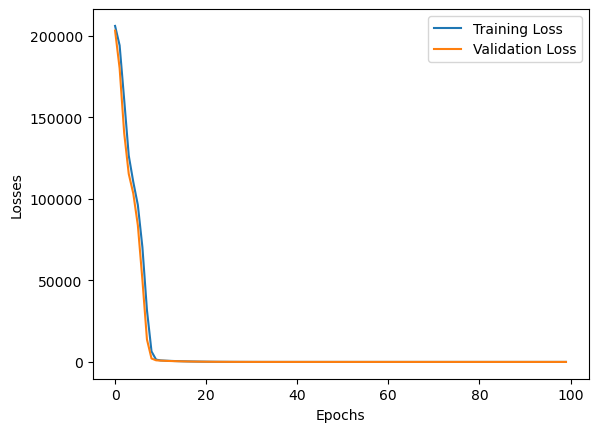

In [39]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [40]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [45]:
# Evaluation

model.eval()
with torch.no_grad():
    train_pred = model(X_train_tensor)
    test_pred = model(X_test_tensor)

    train_mse_loss = crietrion(train_pred,X_train_tensor)
    test_mse_loss = crietrion(test_pred,X_test_tensor)


print("train mse :",train_mse_loss.item())
print("test mse :",test_mse_loss.item())

train mse : 206487.59375
test mse : 206606.328125


C:\Users\prith\anaconda3\envs\torch_env\lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([7654, 4])) that is different to the input size (torch.Size([7654, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
C:\Users\prith\anaconda3\envs\torch_env\lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([1914, 4])) that is different to the input size (torch.Size([1914, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
